## Name : Ankit Vaghela
## USN No : 1AUA23BCS009
## Lab 4: Single Layer Perceptron and MultiLayer Perceptron
## Task 1: Single Layer Perceptron (from scratch)
### Objective: Train a perceptron to classify points based on a linear boundary using Python from first principles

## a. Setup Python Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## b. Define Perceptron Function

In [2]:
# Step 1(b): Perceptron function
def perceptron(x, weights, bias):
    linear = np.dot(x, weights) + bias
    return 1 if linear > 0 else 0

## c. Generate Synthetic Training Data

In [3]:
# Step 1(c): Create data
X = np.array([
    [2, 3],
    [4, 5],
    [1, 1],
    [2, 1],
    [5, 3],
    [6, 2]
])

y = np.array([1, 1, 0, 0, 1, 1])

## d. Train with Perceptron Learning Rule

In [4]:
# Step 1(d): Training
weights = np.zeros(2)
bias = 0
lr = 0.1

for epoch in range(20):
    for i in range(len(X)):
        pred = perceptron(X[i], weights, bias)
        error = y[i] - pred
        
        weights += lr * error * X[i]
        bias += lr * error

print("Weights:", weights)
print("Bias:", bias)

Weights: [0.2 0.3]
Bias: -0.7999999999999999


## e. Visualize Decision Boundary

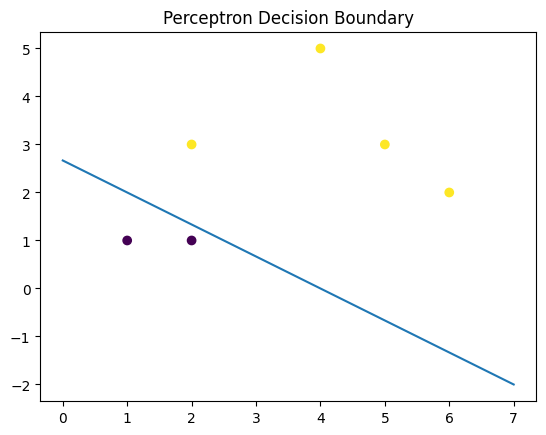

In [5]:
# Step 1(e): Plot decision boundary
x_vals = np.linspace(0,7,100)
y_vals = -(weights[0]*x_vals + bias)/weights[1]

plt.scatter(X[:,0], X[:,1], c=y)
plt.plot(x_vals, y_vals)
plt.title("Perceptron Decision Boundary")
plt.show()

# Task 2: Multi-Layer Perceptron (MLP)
### Objective: Build an MLP classifier using NumPy (from scratch) to learn non-linear decision boundaries.
## a. Define Network Architecture
### For simplicity:
###  Input layer: 2 neurons
### Hidden layer: 4 neurons (ReLU activation)
### Output layer: 1 neuron (sigmoid)

In [6]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

## b. Define Activation Functions

In [7]:
def relu(x):
    return np.maximum(0,x)

def relu_derivative(x):
    return (x>0).astype(float)

def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivative(x):
    return x*(1-x)

## c. Initialize Weights & Biases

In [8]:
# Step 2(c): Initialize weights
np.random.seed(1)

W1 = np.random.randn(2,4)
b1 = np.zeros((1,4))

W2 = np.random.randn(4,1)
b2 = np.zeros((1,1))

lr = 0.1

## d. Train with Backpropagation

In [9]:
for epoch in range(5000):
    
    # Forward
    z1 = np.dot(X,W1) + b1
    a1 = relu(z1)
    
    z2 = np.dot(a1,W2) + b2
    a2 = sigmoid(z2)
    
    # Error
    error = y - a2
    
    # Backprop
    d2 = error * sigmoid_derivative(a2)
    d1 = np.dot(d2,W2.T) * relu_derivative(z1)
    
    # Update
    W2 += lr * np.dot(a1.T,d2)
    b2 += lr * np.sum(d2,0,keepdims=True)
    
    W1 += lr * np.dot(X.T,d1)
    b1 += lr * np.sum(d1,0,keepdims=True)

## e. Evaluate the Model

In [10]:
# Step 2(e): Predictions
print("Predictions:")
print(a2)

Predictions:
[[0.02984763]
 [0.98437829]
 [0.98443733]
 [0.02984763]]


# Task 3: Perform following tasks
### 1. Compare single layer vs MLP on linearly separable vs non-linear data (e.g., XOR).
### 2. Explore how hidden layer size impacts learning.
### 3. Plot loss over training epochs.

Perceptron Linear: 100.0
Perceptron XOR: 50.0
MLP Linear: 100.0
MLP XOR: 100.0


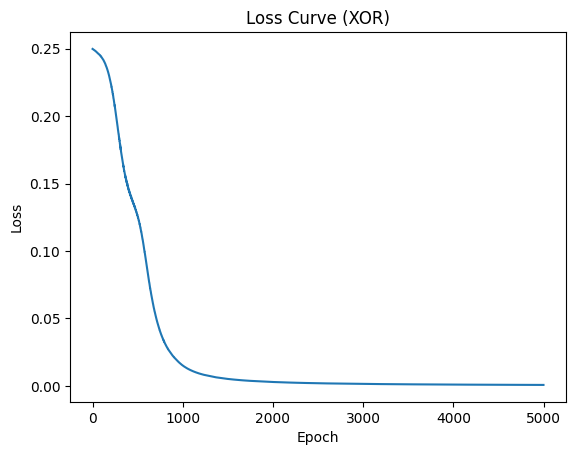

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# -------- DATA --------
np.random.seed(0)

# Linear data
X_lin = np.random.randn(200,2)
y_lin = (X_lin[:,0] + X_lin[:,1] > 0).astype(int)

# XOR data
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], float)
y_xor = np.array([0,1,1,0])

# -------- PERCEPTRON --------
def perceptron(X, y, epochs=50, lr=0.1):
    w = np.zeros(2)
    b = 0
    for _ in range(epochs):
        for xi, yi in zip(X,y):
            pred = 1 if np.dot(xi,w)+b >= 0 else 0
            err = yi - pred
            w += lr*err*xi
            b += lr*err
    return w,b

def predict_p(X,w,b):
    return ((np.dot(X,w)+b)>=0).astype(int)

# -------- MLP --------
def train_mlp(X, y, h=4, epochs=5000, lr=0.1):
    
    y = y.reshape(-1,1)
    
    # Initialize weights
    W1 = np.random.randn(2,h)*0.1
    b1 = np.zeros((1,h))
    W2 = np.random.randn(h,1)*0.1
    b2 = np.zeros((1,1))
    
    losses = []
    
    for _ in range(epochs):
        
        # Forward
        z1 = np.dot(X,W1) + b1
        a1 = np.maximum(0,z1)
        z2 = np.dot(a1,W2) + b2
        a2 = 1/(1+np.exp(-z2))
        
        # Loss
        loss = ((y-a2)**2).mean()
        losses.append(loss)
        
        # Backprop
        d2 = (y-a2)*a2*(1-a2)
        d1 = np.dot(d2,W2.T)*(z1>0)
        
        W2 += lr*np.dot(a1.T,d2)
        b2 += lr*np.sum(d2,0,keepdims=True)
        W1 += lr*np.dot(X.T,d1)
        b1 += lr*np.sum(d1,0,keepdims=True)
    
    return a2, losses

# -------- RUN TEST --------

# Perceptron
w,b = perceptron(X_lin,y_lin)
print("Perceptron Linear:", (predict_p(X_lin,w,b)==y_lin).mean()*100)

w,b = perceptron(X_xor,y_xor)
print("Perceptron XOR:", (predict_p(X_xor,w,b)==y_xor).mean()*100)

# MLP
p1,_ = train_mlp(X_lin,y_lin)
print("MLP Linear:", ((p1>0.5).ravel()==y_lin).mean()*100)

p2,loss = train_mlp(X_xor,y_xor)
print("MLP XOR:", ((p2>0.5).ravel()==y_xor).mean()*100)

# Loss plot
plt.plot(loss)
plt.title("Loss Curve (XOR)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Single Layer Perceptron
### A Single Layer Perceptron is a basic neural network model that uses a linear decisionboundary. It follows the equation: y = w*x + b Where:
### w = weight
### x = input
### b = bias
## Characteristics
### Works only on linearly separable data
### Uses step activation function
### Cannot solve XOR type problems
### Produces straight-line decision boundary
## Multi-Layer Perceptron (MLP)
### A Multi-Layer Perceptron contains one or more hidden layers with non-linear activationfunctions. In this experiment:
### ReLU is used in the hidden layer
### Sigmoid is used in the output layer It follows:
### Hidden Layer Output = ReLU(W1x + b1)
### Final Output = Sigmoid(W2a1 + b2)
## Characteristics:
### Can learn linear and non-linear patterns
### Uses backpropagation for training
### Can solve XOR and complex problems
### Produces curved decision boundary

# 2. Explore how hidden layer size impacts learning.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
def make_xor_data():
    X = np.array([[0,0],[0,1],[1,0],[1,1]], float)
    y = np.array([0,1,1,0])
    return X,y
def relu(x):
    return np.maximum(0,x)
def relu_deriv(x):
    return (x>0).astype(float)
def sigmoid(x):
    return 1/(1+np.exp(-x))
def train_mlp(X,y,h=4,epochs=5000,lr=0.1):
    y=y.reshape(-1,1)
    # weights
    W1=np.random.randn(2,h)*0.1
    b1=np.zeros((1,h))
    W2=np.random.randn(h,1)*0.1
    b2=np.zeros((1,1))
    losses=[]
    for _ in range(epochs):
        # forward
        z1=np.dot(X,W1)+b1
        a1=relu(z1)
        z2=np.dot(a1,W2)+b2
        a2=sigmoid(z2)
        # loss
        loss=((y-a2)**2).mean()
        losses.append(loss)
        # backward
        d2=(y-a2)*a2*(1-a2)
        d1=np.dot(d2,W2.T)*relu_deriv(z1)
        # update
        W2+=lr*np.dot(a1.T,d2)
        b2+=lr*np.sum(d2,0,keepdims=True)
        W1+=lr*np.dot(X.T,d1)
        b1+=lr*np.sum(d1,0,keepdims=True)
    return (W1,b1,W2,b2), losses
def predict_mlp(X,params):
    W1,b1,W2,b2=params
    a1=relu(np.dot(X,W1)+b1)
    a2=sigmoid(np.dot(a1,W2)+b2)
    return (a2>=0.5).astype(int).ravel()
def accuracy(y_true,y_pred):
    return (y_true==y_pred).mean()*100
X_xor,y_xor=make_xor_data()
print("\nHidden Layer Size Impact (XOR)\n")
for h in [1,2,4,8,16]:
    params,_=train_mlp(X_xor,y_xor,h=h,epochs=10000)
    pred=predict_mlp(X_xor,params)
    acc=accuracy(y_xor,pred)
    print("Hidden =",h," -> Accuracy =",round(acc,2),"%")


Hidden Layer Size Impact (XOR)

Hidden = 1  -> Accuracy = 75.0 %
Hidden = 2  -> Accuracy = 50.0 %
Hidden = 4  -> Accuracy = 100.0 %
Hidden = 8  -> Accuracy = 75.0 %
Hidden = 16  -> Accuracy = 100.0 %


## Observations:
### Small hidden layer -> Low learning (Underfitting)
### Medium hidden layer -> Good learning
### Large hidden layer -> Better feature extraction
### More neurons allow the network to learn complex patterns effectively
### Very large layers may cause overfitting

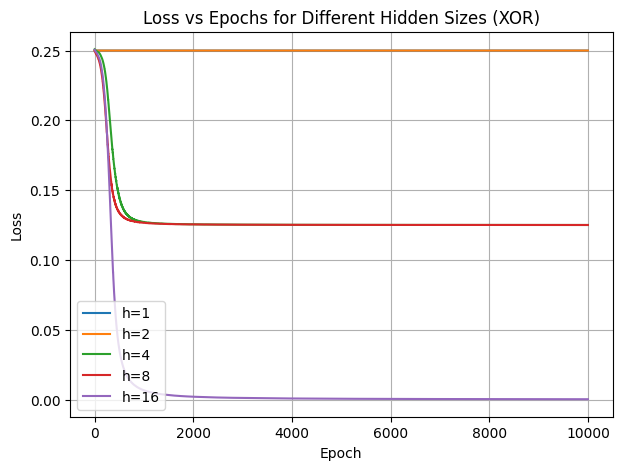

In [13]:
plt.figure(figsize=(7,5))
for h in [1,2,4,8,16]:
    params, losses = train_mlp(X_xor, y_xor, h=h, epochs=10000)
    plt.plot(losses, label="h="+str(h))
plt.title("Loss vs Epochs for Different Hidden Sizes (XOR)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()